In [75]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [76]:
df=pd.read_csv("D:/DAMI (Data Mining)/Final Project/heart_2020_cleaned_FromKagle.csv")

In [77]:
df

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319790,Yes,27.41,Yes,No,No,7.0,0.0,Yes,Male,60-64,Hispanic,Yes,No,Fair,6.0,Yes,No,No
319791,No,29.84,Yes,No,No,0.0,0.0,No,Male,35-39,Hispanic,No,Yes,Very good,5.0,Yes,No,No
319792,No,24.24,No,No,No,0.0,0.0,No,Female,45-49,Hispanic,No,Yes,Good,6.0,No,No,No
319793,No,32.81,No,No,No,0.0,0.0,No,Female,25-29,Hispanic,No,No,Good,12.0,No,No,No


In [78]:
# Chọn các cột muốn giữ lại
df_selected = df[['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime','Sex']]
df_selected

,BMI,PhysicalHealth,MentalHealth,SleepTime,Sex
0,16.60,3.0,30.0,5.0,Female
1,20.34,0.0,0.0,7.0,Female
2,26.58,20.0,30.0,8.0,Male
3,24.21,0.0,0.0,6.0,Female
4,23.71,28.0,0.0,8.0,Female
...,...,...,...,...,...
319790,27.41,7.0,0.0,6.0,Male
319791,29.84,0.0,0.0,5.0,Male
319792,24.24,0.0,0.0,6.0,Female
319793,32.81,0.0,0.0,12.0,Female


In [79]:
# Thay thế giá trị trong cột 'Sex' )
df_selected['Sex'] = df_selected['Sex'].map({'Male': 1, 'Female': 0})
df_selected

C:\Users\admin\AppData\Local\Temp\ipykernel_11844\1800921530.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['Sex'] = df_selected['Sex'].map({'Male': 1, 'Female': 0})


,BMI,PhysicalHealth,MentalHealth,SleepTime,Sex
0,16.60,3.0,30.0,5.0,0
1,20.34,0.0,0.0,7.0,0
2,26.58,20.0,30.0,8.0,1
3,24.21,0.0,0.0,6.0,0
4,23.71,28.0,0.0,8.0,0
...,...,...,...,...,...
319790,27.41,7.0,0.0,6.0,1
319791,29.84,0.0,0.0,5.0,1
319792,24.24,0.0,0.0,6.0,0
319793,32.81,0.0,0.0,12.0,0


<Axes: xlabel='SleepTime', ylabel='MentalHealth'>

C:\Users\admin\AppData\Roaming\Python\Python39\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\admin\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


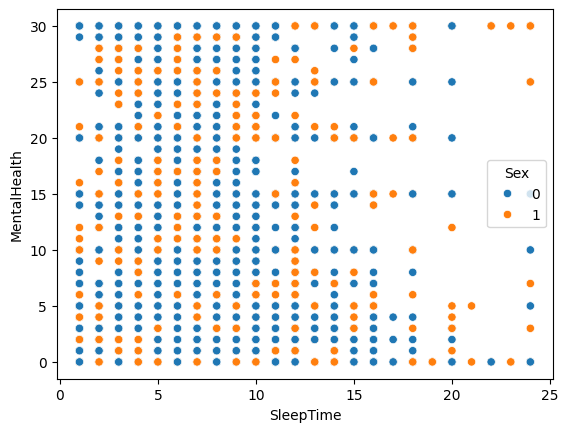

In [83]:
sns.scatterplot(data=df_selected,x='SleepTime',y='MentalHealth', hue='Sex')

In [81]:
#sns.scatterplot(data=df_selected,x='PhysicalHealth',y='MentalHealth', hue='Sex')

Scale dữ liệu

In [82]:
#print('mối tương quan giữa các loại danh mục')
scaler = StandardScaler()
scaled_X = scaler.fit_transform(df_selected)

In [84]:
number_of_noise_points = [] #số lượng outliers
percentage_of_noise_points = [] #tỷ lệ outliers so với tổng số điểm

min_points = 20 #có thể thay đổi tùy thích

for eps in np.linspace(0.1,3,25): #duyệt qua một dãy giá trị eps từ 0.001 đến 3 với 50 điểm
    # tạo model
    dbscan = DBSCAN(eps=eps,min_samples=min_points)
    dbscan.fit(scaled_X)

    # số lượng outliers
    number_of_noise_points.append(np.sum(dbscan.labels_==-1)) #thêm số lượng điểm (-1) vào number_of_noise_points

    #Lưu tỷ lệ (giữa outliers và tất cả các điểm) vào biến perc_noise_points
    perc_noise_points= 100*np.sum(dbscan.labels_==-1)/len(dbscan.labels_)

    #Thêm tỷ lệ perc_noise_points vào percentage_of_noise_points.
    percentage_of_noise_points.append(perc_noise_points)
 
sns.lineplot(x=np.linspace(0.001, 3, 50), y=number_of_noise_points)

plt.xlabel('Giá trị epsilon')
plt.ylabel('Tỷ lệ của outliers')

In [ ]:
dbscan = DBSCAN(eps=2.0,min_samples= min_points)
dbscan.fit(scaled_X)

In [ ]:
plt.figure(figsize=(8,5), dpi=150)
sns.scatterplot(data=df, x='SleepTime', y='MentalHealth', hue=dbscan.labels_, palette='Set1')
plt.title("Các cụm được xác định bởi DBSCAN")